In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, ConfusionMatrixDisplay
)
from sklearn.preprocessing import MinMaxScaler
import joblib
import json
import warnings
warnings.filterwarnings("ignore")

DATA_DIR  = Path("../data/processed/FD001")
RAW_DIR   = Path("../data/raw")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# load balanced training data (real + synthetic)
X_train  = np.load(DATA_DIR / "X_balanced.npy")
y_train  = np.load(DATA_DIR / "labels_balanced.npy")

FEATURE_COLS = [
    "op1","op2",
    "s2","s3","s4","s7","s8","s9",
    "s11","s12","s13","s14","s15","s17","s20","s21",
]
CLASS_NAMES  = ["C0 healthy", "C1 early", "C2 advanced", "C3 imminent"]
NUM_CLASSES  = 4
SEQ_LEN      = X_train.shape[1]
INPUT_DIM    = X_train.shape[2]

print(f"X_train  : {X_train.shape}")
print(f"y_train  : {y_train.shape}")
print(f"Device   : {DEVICE}")
from collections import Counter
print(f"Class dist: {Counter(y_train.tolist())}")

X_train  : (30532, 30, 16)
y_train  : (30532,)
Device   : cpu
Class dist: Counter({2: 7633, 0: 7633, 1: 7633, 3: 7633})


In [2]:
COLUMNS = (
    ["engine_id", "cycle"]
    + [f"op{i}" for i in range(1, 4)]
    + [f"s{i}"  for i in range(1, 22)]
)

DROP_COLS = ["s1","s5","s6","s10","s16","s18","s19","op3"]

def load_cmapss(path):
    df = pd.read_csv(path, sep=r"\s+", header=None)
    df = df.iloc[:, :len(COLUMNS)]
    df.columns = COLUMNS
    df = df.apply(pd.to_numeric, errors="coerce")
    return df

def preprocess_test(df, global_scaler, engine_scalers):
    df = df.copy()
    df = df.drop(columns=DROP_COLS, errors="ignore")

    GLOBAL_SCALE = ["s3"]
    PER_ENGINE   = [f for f in FEATURE_COLS if f not in GLOBAL_SCALE]

    # apply saved scalers — never refit on test data
    df[GLOBAL_SCALE] = global_scaler.transform(df[GLOBAL_SCALE])

    scaled_parts = []
    for engine_id, group in df.groupby("engine_id"):
        group = group.copy()
        if engine_id in engine_scalers:
            scaler = engine_scalers[engine_id]
            group[PER_ENGINE] = scaler.transform(group[PER_ENGINE])
        else:
            # unseen engine — use mean of all scalers
            group[PER_ENGINE] = MinMaxScaler().fit_transform(group[PER_ENGINE])
        scaled_parts.append(group)

    return pd.concat(scaled_parts).sort_values(["engine_id","cycle"]).reset_index(drop=True)


# load scalers saved in Phase 2
global_scaler  = joblib.load(DATA_DIR / "global_scaler.pkl")
engine_scalers = joblib.load(DATA_DIR / "engine_scalers.pkl")

# load test set
test_raw = load_cmapss(RAW_DIR / "test_FD001.txt")
test_df  = preprocess_test(test_raw, global_scaler, engine_scalers)

# load ground truth RUL
rul_df = pd.read_csv(RAW_DIR / "RUL_FD001.txt", header=None, names=["RUL"])
rul_df["engine_id"] = range(1, len(rul_df)+1)

print(f"Test engines : {test_df['engine_id'].nunique()}")
print(f"Test shape   : {test_df.shape}")
print(f"RUL labels   : {rul_df.shape}")

Test engines : 100
Test shape   : (13096, 18)
RUL labels   : (100, 2)


In [3]:
def get_last_window(df, window_size=30):
    """
    For each engine take the last W cycles as the prediction window.
    This matches the CMAPSS evaluation protocol.
    """
    X_test = []
    engine_ids = []

    for engine_id, group in df.groupby("engine_id"):
        group = group.sort_values("cycle")
        feats = group[FEATURE_COLS].values

        if len(feats) >= window_size:
            window = feats[-window_size:]
        else:
            # pad with zeros if engine has fewer cycles than window
            pad    = np.zeros((window_size - len(feats), feats.shape[1]))
            window = np.vstack([pad, feats])

        X_test.append(window)
        engine_ids.append(engine_id)

    return np.array(X_test, dtype=np.float32), engine_ids


X_test, engine_ids = get_last_window(test_df, window_size=SEQ_LEN)

# assign fault class labels from ground truth RUL
def rul_to_class(rul):
    if rul > 100: return 0
    elif rul > 50: return 1
    elif rul > 10: return 2
    else: return 3

y_test_rul = rul_df["RUL"].values
y_test     = np.array([rul_to_class(r) for r in y_test_rul], dtype=np.int64)

print(f"X_test shape : {X_test.shape}")
print(f"y_test shape : {y_test.shape}")
print(f"Test class dist: {Counter(y_test.tolist())}")

X_test shape : (100, 30, 16)
y_test shape : (100,)
Test class dist: Counter({1: 34, 0: 33, 2: 26, 3: 7})


In [4]:
class FaultDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 64

train_dataset = FaultDataset(X_train, y_train)
test_dataset  = FaultDataset(X_test,  y_test)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Test batches  : {len(test_loader)}")

Train batches : 477
Test batches  : 2


In [5]:
class FaultClassifier1DCNN(nn.Module):
    """
    1D CNN over time axis for fault classification.
    Input : (batch, seq_len, input_dim)
    Output: (batch, num_classes)
    """
    def __init__(self, input_dim, seq_len, num_classes):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv1d(input_dim, 64,  kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64,        128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(8),   # -> (B, 128, 8)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        # x: (B, T, D) -> (B, D, T) for Conv1d
        x = x.permute(0, 2, 1)
        x = self.conv_block(x)
        return self.classifier(x)


model = FaultClassifier1DCNN(INPUT_DIM, SEQ_LEN, NUM_CLASSES).to(DEVICE)
print(model)
print(f"\nParameters: {sum(p.numel() for p in model.parameters()):,}")

FaultClassifier1DCNN(
  (conv_block): Sequential(
    (0): Conv1d(16, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): AdaptiveAvgPool1d(output_size=8)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1024, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=4, bias=True)
  )
)

Parameters: 307,332


In [6]:
EPOCHS   = 50
LR       = 1e-3

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss()

history = {"train_loss": [], "train_acc": []}

print(f"Training 1D-CNN classifier for {EPOCHS} epochs...")
for epoch in range(EPOCHS):
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        logits = model(x_batch)
        loss   = criterion(logits, y_batch)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        preds = logits.argmax(dim=1)
        total_loss    += loss.item() * len(y_batch)
        total_correct += (preds == y_batch).sum().item()
        total_samples += len(y_batch)

    scheduler.step()

    avg_loss = total_loss / total_samples
    avg_acc  = total_correct / total_samples
    history["train_loss"].append(avg_loss)
    history["train_acc"].append(avg_acc)

    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1:>3}/{EPOCHS}  loss={avg_loss:.4f}  acc={avg_acc:.4f}")

print("Training complete.")

Training 1D-CNN classifier for 50 epochs...
  Epoch  10/50  loss=0.0506  acc=0.9808
  Epoch  20/50  loss=0.0239  acc=0.9916
  Epoch  30/50  loss=0.0072  acc=0.9974
  Epoch  40/50  loss=0.0008  acc=0.9998
  Epoch  50/50  loss=0.0004  acc=1.0000
Training complete.


In [7]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(DEVICE)
        logits  = model(x_batch)
        preds   = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

acc = accuracy_score(all_labels, all_preds)
f1  = f1_score(all_labels, all_preds, average="weighted")

print(f"Test Accuracy         : {acc:.4f}")
print(f"Test F1 (weighted)    : {f1:.4f}")
print()
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

Test Accuracy         : 0.5600
Test F1 (weighted)    : 0.5574

              precision    recall  f1-score   support

  C0 healthy       0.53      0.70      0.61        33
    C1 early       0.57      0.38      0.46        34
 C2 advanced       0.87      0.50      0.63        26
 C3 imminent       0.37      1.00      0.54         7

    accuracy                           0.56       100
   macro avg       0.58      0.64      0.56       100
weighted avg       0.62      0.56      0.56       100



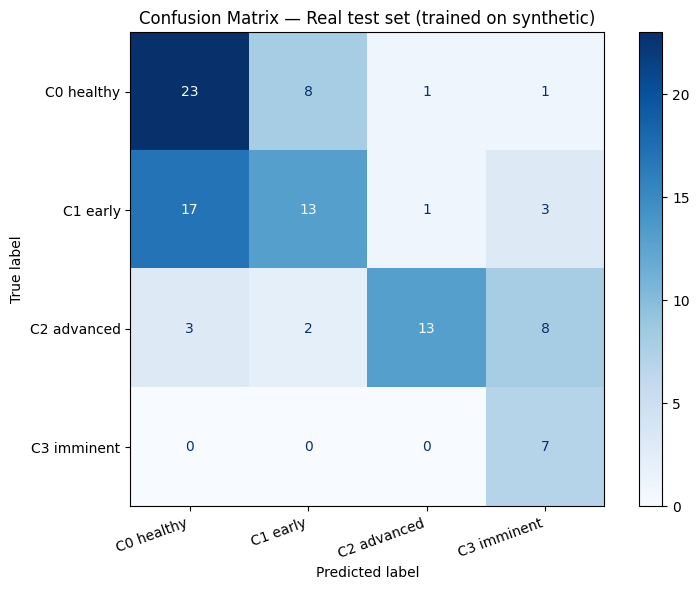

In [8]:
cm  = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title("Confusion Matrix — Real test set (trained on synthetic)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("../reports/figures/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

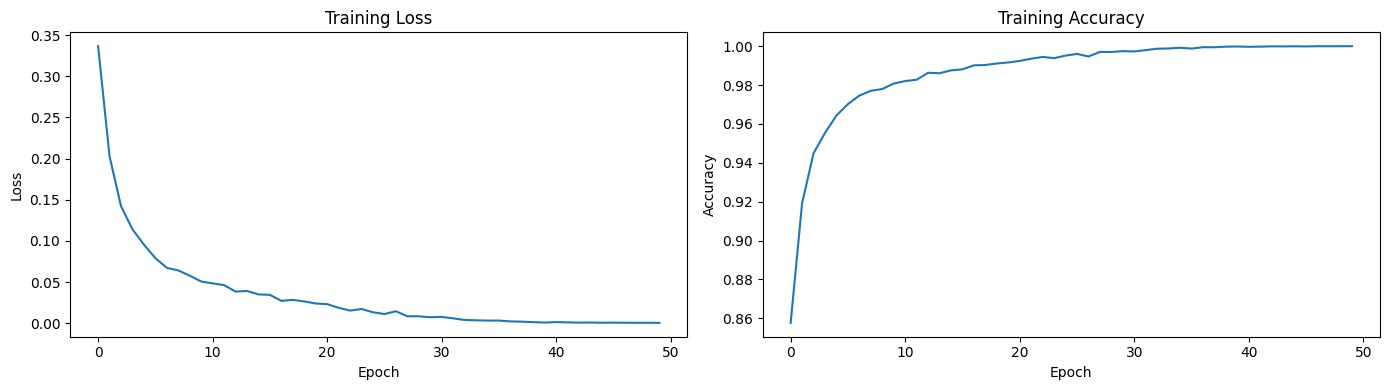

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history["train_loss"])
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

axes[1].plot(history["train_acc"])
axes[1].set_title("Training Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")

plt.tight_layout()
plt.savefig("../reports/figures/classifier_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# For each test engine compute predicted class and compare to real RUL
pred_classes = all_preds
true_classes = all_labels
true_rul     = y_test_rul[:len(pred_classes)]

# class midpoint RUL estimates
CLASS_RUL_MIDPOINT = {0: 125, 1: 75, 2: 30, 3: 5}

pred_rul = np.array([CLASS_RUL_MIDPOINT[c] for c in pred_classes])
rmse     = np.sqrt(np.mean((pred_rul - true_rul[:len(pred_rul)]) ** 2))

print(f"RUL RMSE (class midpoint estimate): {rmse:.2f} cycles")

# per class RMSE
print("\nPer-class RMSE:")
for c in range(NUM_CLASSES):
    mask = true_classes == c
    if mask.sum() == 0:
        continue
    c_rmse = np.sqrt(np.mean(
        (pred_rul[mask] - true_rul[:len(pred_rul)][mask]) ** 2
    ))
    print(f"  {CLASS_NAMES[c]:<20}: RMSE={c_rmse:.2f}  n={mask.sum()}")

RUL RMSE (class midpoint estimate): 36.54 cycles

Per-class RMSE:
  C0 healthy          : RMSE=35.70  n=33
  C1 early            : RMSE=40.33  n=34
  C2 advanced         : RMSE=37.25  n=26
  C3 imminent         : RMSE=3.72  n=7


In [11]:
torch.save(model.state_dict(), DATA_DIR / "classifier_1dcnn.pt")

results = {
    "test_accuracy"  : round(float(acc), 4),
    "test_f1_weighted": round(float(f1), 4),
    "rul_rmse"       : round(float(rmse), 2),
    "class_report"   : classification_report(
        all_labels, all_preds,
        target_names=CLASS_NAMES,
        output_dict=True
    ),
}

with open(DATA_DIR / "phase8_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("=" * 45)
print("      PHASE 8 SUMMARY")
print("=" * 45)
print(f"Test Accuracy    : {acc:.4f}")
print(f"Test F1 weighted : {f1:.4f}")
print(f"RUL RMSE         : {rmse:.2f} cycles")
print("=" * 45)
print("Saved classifier_1dcnn.pt and phase8_results.json")

      PHASE 8 SUMMARY
Test Accuracy    : 0.5600
Test F1 weighted : 0.5574
RUL RMSE         : 36.54 cycles
Saved classifier_1dcnn.pt and phase8_results.json
